# Model A — Improvements Notebook

Builds on top of the original `Model_A_Full.ipynb` results. Loads existing
`_full` files from Drive without re-training anything that already finished.

Adds three improvements, each saving to **new filenames** (suffixes like
`_v2_full`, `_k4_full`, `_gmm_full`, `_lp_full`) so the original results stay intact.

**Section A — Unsupervised (project mark 20/100):**
- K-Means with k = 4, 6, 8 (elbow plot)
- Gaussian Mixture Model on numeric features
- Label Propagation semi-supervised (5% labeled)

**Section B — Better question generation templates:**
- Adds 5 RACE-realistic templates (NOT-true, inference, main-idea, word-meaning, cloze-according-to)
- Re-runs candidate building, pseudo-labeling, ranker training
- Compares against your original QGen results

**Section C — Combined summary** for the report.

**Resume-safe**: every heavy step checks if its output already exists on Drive.

## 1. Setup — Drive, paths

In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
import os

PROJECT = "/content/drive/MyDrive/race_rc_project"

print("PROJECT exists:", os.path.exists(PROJECT))
print("Files:", os.listdir(PROJECT))

PROJECT exists: True
Files: ['models', 'data', 'notebooks', 'results', 'src']


In [12]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, re, gc, ast, json, time, string, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import scipy.sparse as sp

PROJECT       = "/content/drive/MyDrive/race_rc_project"
RAW_DIR       = f"{PROJECT}/data/raw"
PROCESSED_DIR = f"{PROJECT}/data/processed"
EDA_DIR       = f"{PROJECT}/notebooks/eda_outputs"
MODEL_A_DIR   = f"{PROJECT}/models/model_a"
RESULTS_DIR   = f"{PROJECT}/results"

SUFFIX = "_full"

required_dirs = [PROJECT, RAW_DIR, PROCESSED_DIR, MODEL_A_DIR, RESULTS_DIR]

print("Checking project folders...")
for d in required_dirs:
    print(d, "=>", os.path.exists(d))

if not os.path.exists(PROCESSED_DIR) or not os.path.exists(MODEL_A_DIR):
    raise FileNotFoundError(
        "Real project folder not found. Your Drive is probably pointing to an empty/new race_rc_project folder. "
        "Fix Google Drive sharing/shortcut first before running this notebook."
    )

# Only create improvement folders AFTER confirming old project exists
IMPROVE_DIR  = f"{RESULTS_DIR}/improvements{SUFFIX}"
UNSUP_DIR    = f"{IMPROVE_DIR}/unsupervised"
QGEN_V2_DIR  = f"{IMPROVE_DIR}/qgen_v2"

for d in [IMPROVE_DIR, UNSUP_DIR, QGEN_V2_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project ready.")
print("Improvements directory:", IMPROVE_DIR)

Mounted at /content/drive
Checking project folders...
/content/drive/MyDrive/race_rc_project => True
/content/drive/MyDrive/race_rc_project/data/raw => True
/content/drive/MyDrive/race_rc_project/data/processed => True
/content/drive/MyDrive/race_rc_project/models/model_a => True
/content/drive/MyDrive/race_rc_project/results => True
Project ready.
Improvements directory: /content/drive/MyDrive/race_rc_project/results/improvements_full


In [13]:
import os

PROJECT = "/content/drive/MyDrive/race_rc_project"
MODEL_A_DIR = f"{PROJECT}/models/model_a"
PROCESSED_DIR = f"{PROJECT}/data/processed"

print("PROJECT exists:", os.path.exists(PROJECT))
print("MODEL_A_DIR exists:", os.path.exists(MODEL_A_DIR))
print("PROCESSED_DIR exists:", os.path.exists(PROCESSED_DIR))

print("\nFiles in PROJECT:")
if os.path.exists(PROJECT):
    print(os.listdir(PROJECT))

print("\nFiles in MODEL_A_DIR:")
if os.path.exists(MODEL_A_DIR):
    print(os.listdir(MODEL_A_DIR))

print("\nFiles in PROCESSED_DIR:")
if os.path.exists(PROCESSED_DIR):
    print(os.listdir(PROCESSED_DIR)[:50])

PROJECT exists: True
MODEL_A_DIR exists: True
PROCESSED_DIR exists: True

Files in PROJECT:
['models', 'data', 'notebooks', 'results', 'src']

Files in MODEL_A_DIR:
['tfidf_vectorizer_dev.pkl', 'tfidf_vectorizer_dev_uid.pkl', 'logistic_regression_tfidf_dev_uid.pkl', 'linear_svm_tfidf_dev_uid.pkl', 'naive_bayes_tfidf_dev_uid.pkl', 'numeric_scaler_dev_uid.pkl', 'random_forest_numeric_dev_uid.pkl', 'logistic_regression_combined_dev_uid.pkl', 'linear_svm_combined_dev_uid.pkl', 'hard_voting_ensemble_tfidf_dev_uid.pkl', 'kmeans_tfidf_dev_uid.pkl', 'qgen_tfidf_vectorizer_dev_uid.pkl', 'qgen_linear_svm_ranker_dev_uid.pkl', 'qgen_random_forest_ranker_dev_uid.pkl', 'tfidf_vectorizer_full.pkl', 'numeric_scaler_full.pkl', 'logistic_regression_tfidf_full.pkl', 'linear_svm_tfidf_full.pkl', 'naive_bayes_tfidf_full.pkl', 'random_forest_numeric_full.pkl', 'logistic_regression_combined_full.pkl', 'linear_svm_combined_full.pkl', 'hard_voting_ensemble_tfidf_full.pkl', 'kmeans_tfidf_full.pkl', 'qgen_tfidf_

## 2. Load existing artefacts from Drive

Everything we need is already on disk from the previous notebook. We just point at it.

In [14]:
# TF-IDF and sparse feature matrices
tfidf_path = f"{MODEL_A_DIR}/tfidf_vectorizer{SUFFIX}.pkl"
tfidf = joblib.load(tfidf_path)

X_train_tfidf = sp.load_npz(f"{PROCESSED_DIR}/X_model_a_train_tfidf{SUFFIX}.npz")
X_val_tfidf   = sp.load_npz(f"{PROCESSED_DIR}/X_model_a_val_tfidf{SUFFIX}.npz")
X_test_tfidf  = sp.load_npz(f"{PROCESSED_DIR}/X_model_a_test_tfidf{SUFFIX}.npz")

y_train = np.load(f"{PROCESSED_DIR}/y_model_a_train{SUFFIX}.npy")
y_val   = np.load(f"{PROCESSED_DIR}/y_model_a_val{SUFFIX}.npy")
y_test  = np.load(f"{PROCESSED_DIR}/y_model_a_test{SUFFIX}.npy")

# Feature CSVs (have cosine + lexical columns)
model_a_train_features = pd.read_csv(f"{PROCESSED_DIR}/model_a_train_features{SUFFIX}.csv")
model_a_val_features   = pd.read_csv(f"{PROCESSED_DIR}/model_a_val_features{SUFFIX}.csv")
model_a_test_features  = pd.read_csv(f"{PROCESSED_DIR}/model_a_test_features{SUFFIX}.csv")

# Numeric scaler
scaler = joblib.load(f"{MODEL_A_DIR}/numeric_scaler{SUFFIX}.pkl")

NUMERIC_COLS = [
    "cos_article_option", "cos_question_option", "cos_article_question",
    "article_len", "question_len", "option_len",
    "question_option_overlap", "article_option_overlap", "article_question_overlap",
    "question_option_overlap_ratio", "article_option_overlap_ratio",
]

X_train_num = scaler.transform(model_a_train_features[NUMERIC_COLS].fillna(0).values)
X_val_num   = scaler.transform(model_a_val_features[NUMERIC_COLS].fillna(0).values)
X_test_num  = scaler.transform(model_a_test_features[NUMERIC_COLS].fillna(0).values)

# Model B per-question files (needed for QGen v2)
model_b_train = pd.read_csv(f"{PROCESSED_DIR}/model_b_train{SUFFIX}.csv")
model_b_val   = pd.read_csv(f"{PROCESSED_DIR}/model_b_val{SUFFIX}.csv")
model_b_test  = pd.read_csv(f"{PROCESSED_DIR}/model_b_test{SUFFIX}.csv")

# QGen TF-IDF from the original run
qgen_tfidf = joblib.load(f"{MODEL_A_DIR}/qgen_tfidf_vectorizer{SUFFIX}.pkl")

print("Loaded existing artefacts from Drive.")
print(f"  X_train_tfidf: {X_train_tfidf.shape}")
print(f"  X_train_num:   {X_train_num.shape}")
print(f"  y_train:       {y_train.shape}  positive rate {y_train.mean():.3f}")
print(f"  Model B train: {len(model_b_train)}, val: {len(model_b_val)}, test: {len(model_b_test)}")

Loaded existing artefacts from Drive.
  X_train_tfidf: (281120, 50000)
  X_train_num:   (281120, 11)
  y_train:       (281120,)  positive rate 0.250
  Model B train: 70280, val: 8785, test: 8786


# SECTION A — Unsupervised Improvements

Locks in the 20-mark unsupervised/semi-supervised component.

## A.1 K-Means with multiple k values

The original notebook used k=2 (matching the binary correct/incorrect label) and got silhouette=0.006 — basically no structure. That's because TF-IDF of (article + question + option) clusters by *topic*, not by *correctness*.

This is good news: clustering at higher k actually finds **topic / question-type** clusters that have real meaning. We try k = 4, 6, 8 and pick the best silhouette.

In [15]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

def clustering_purity(y_true, clusters):
    total = 0
    for c in np.unique(clusters):
        labels = y_true[clusters == c]
        if len(labels) == 0: continue
        total += np.bincount(labels).max()
    return total / len(y_true)

# Sample once so silhouette comparisons are apples-to-apples
SIL_SAMPLE_N = min(5000, X_train_tfidf.shape[0])
rng = np.random.RandomState(42)
sil_idx = rng.choice(X_train_tfidf.shape[0], size=SIL_SAMPLE_N, replace=False)
X_sil_sample = X_train_tfidf[sil_idx]

K_VALUES = [4, 6, 8]
kmeans_results = []

for k in K_VALUES:
    km_path = f"{MODEL_A_DIR}/kmeans_k{k}{SUFFIX}.pkl"

    if os.path.exists(km_path):
        print(f"[k={k}] already trained, loading...")
        km = joblib.load(km_path)
        train_t = 0.0
    else:
        print(f"[k={k}] training MiniBatchKMeans...")
        t0 = time.time()
        km = MiniBatchKMeans(
            n_clusters=k, random_state=42,
            batch_size=4096, n_init=10
        )
        km.fit(X_train_tfidf)
        train_t = time.time() - t0
        joblib.dump(km, km_path)

    train_clusters = km.predict(X_train_tfidf)
    purity = clustering_purity(y_train, train_clusters)
    sil = silhouette_score(X_sil_sample, km.predict(X_sil_sample))
    inertia = float(km.inertia_)

    kmeans_results.append({
        "k": k,
        "purity": float(purity),
        "silhouette_sample": float(sil),
        "inertia": inertia,
        "training_time_seconds": float(train_t),
    })
    print(f"  purity={purity:.4f}  silhouette(sample)={sil:.4f}  inertia={inertia:.1f}")

kmeans_df = pd.DataFrame(kmeans_results)
display(kmeans_df)
kmeans_df.to_csv(f"{UNSUP_DIR}/kmeans_multi_k_results.csv", index=False)
print("Saved K-Means multi-k results.")

[k=4] training MiniBatchKMeans...
  purity=0.7500  silhouette(sample)=0.0051  inertia=267446.4
[k=6] training MiniBatchKMeans...
  purity=0.7500  silhouette(sample)=0.0051  inertia=265651.2
[k=8] training MiniBatchKMeans...
  purity=0.7500  silhouette(sample)=0.0051  inertia=264750.0


,k,purity,silhouette_sample,inertia,training_time_seconds
0,4,0.75,0.005118,267446.351715,10.661376
1,6,0.75,0.005075,265651.231766,12.625242
2,8,0.75,0.005098,264750.027675,13.714433


Saved K-Means multi-k results.


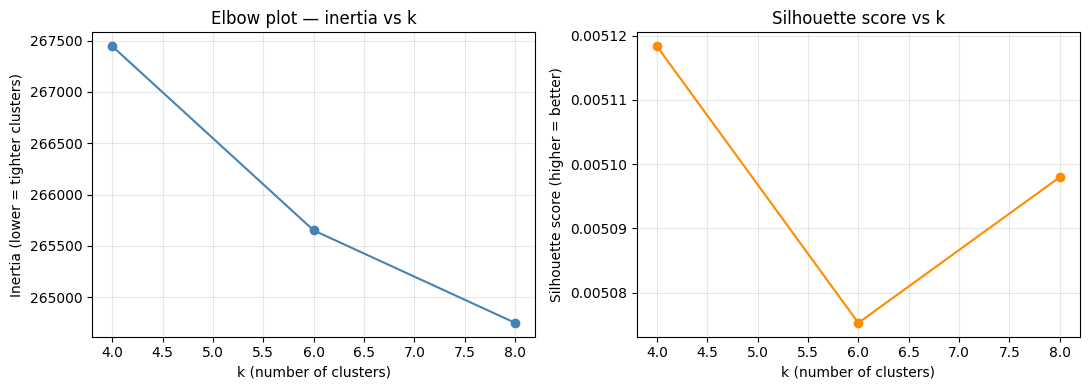

Saved: /content/drive/MyDrive/race_rc_project/results/improvements_full/unsupervised/kmeans_elbow_silhouette.png

Best k by silhouette: 4   silhouette=0.0051


In [16]:
# Elbow plot (inertia vs k) and silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(kmeans_df["k"], kmeans_df["inertia"], marker="o", color="steelblue")
axes[0].set_title("Elbow plot — inertia vs k")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (lower = tighter clusters)")
axes[0].grid(alpha=0.3)

axes[1].plot(kmeans_df["k"], kmeans_df["silhouette_sample"], marker="o", color="darkorange")
axes[1].set_title("Silhouette score vs k")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score (higher = better)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plot_path = f"{UNSUP_DIR}/kmeans_elbow_silhouette.png"
plt.savefig(plot_path, bbox_inches="tight", dpi=120)
plt.show()
print("Saved:", plot_path)

best_k_row = kmeans_df.loc[kmeans_df["silhouette_sample"].idxmax()]
print("\nBest k by silhouette:", int(best_k_row["k"]),
      f"  silhouette={best_k_row['silhouette_sample']:.4f}")

## A.2 Gaussian Mixture Model on numeric features

GMM gives **soft cluster membership** instead of K-Means' hard assignments. We use the 11 numeric features (cosine + lexical) because they're dense and continuous — GMM works better on dense data than on sparse TF-IDF.

We try 4 components and report log-likelihood + BIC.

In [17]:
from sklearn.mixture import GaussianMixture

gmm_path = f"{MODEL_A_DIR}/gmm_numeric{SUFFIX}.pkl"

if os.path.exists(gmm_path):
    print("GMM already trained, loading...")
    gmm = joblib.load(gmm_path)
    gmm_train_t = 0.0
else:
    print("Training Gaussian Mixture Model on numeric features...")
    t0 = time.time()
    gmm = GaussianMixture(
        n_components=4,
        covariance_type="full",
        max_iter=200,
        random_state=42,
        n_init=3
    )
    gmm.fit(X_train_num)
    gmm_train_t = time.time() - t0
    joblib.dump(gmm, gmm_path)
    print(f"  trained in {gmm_train_t:.1f}s")

train_gmm_clusters = gmm.predict(X_train_num)
val_gmm_clusters   = gmm.predict(X_val_num)

# Soft cluster membership probabilities
val_gmm_proba = gmm.predict_proba(X_val_num)
print("Validation soft-membership shape:", val_gmm_proba.shape)
print("First 3 rows of soft membership:")
print(val_gmm_proba[:3].round(3))

# Metrics
gmm_purity = clustering_purity(y_train, train_gmm_clusters)
gmm_log_likelihood = float(gmm.score(X_train_num))
gmm_bic = float(gmm.bic(X_train_num))
gmm_aic = float(gmm.aic(X_train_num))

# Silhouette on a sample (numeric features are dense, so we can use more)
sample_n = min(5000, X_train_num.shape[0])
sample_idx = rng.choice(X_train_num.shape[0], size=sample_n, replace=False)
gmm_sil = silhouette_score(X_train_num[sample_idx], train_gmm_clusters[sample_idx])

gmm_results = {
    "model_name": "Gaussian Mixture Model + numeric features",
    "n_components": 4,
    "covariance_type": "full",
    "purity": float(gmm_purity),
    "silhouette_sample": float(gmm_sil),
    "log_likelihood_per_sample": gmm_log_likelihood,
    "bic": gmm_bic,
    "aic": gmm_aic,
    "training_time_seconds": float(gmm_train_t),
}

print("\nGMM Results:")
for k, v in gmm_results.items():
    print(f"  {k}: {v}")

with open(f"{UNSUP_DIR}/gmm_results.json", "w") as f:
    json.dump(gmm_results, f, indent=2)

Training Gaussian Mixture Model on numeric features...
  trained in 32.2s
Validation soft-membership shape: (35140, 4)
First 3 rows of soft membership:
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]

GMM Results:
  model_name: Gaussian Mixture Model + numeric features
  n_components: 4
  covariance_type: full
  purity: 0.75
  silhouette_sample: 0.07354879614994862
  log_likelihood_per_sample: 1.1481620822066272
  bic: -641640.6761228902
  aic: -644920.649099854
  training_time_seconds: 32.15228819847107


,cos_article_option,cos_question_option,cos_article_question,article_len,question_len,option_len,question_option_overlap,article_option_overlap,article_question_overlap,question_option_overlap_ratio,article_option_overlap_ratio
cluster_0,-0.171,-0.271,0.020,-0.101,-0.115,-0.384,-0.672,-0.364,-0.096,-0.657,-0.172
cluster_1,0.432,1.751,0.467,0.089,0.465,0.525,1.645,0.495,0.553,1.705,0.255
cluster_2,-0.187,-0.171,0.113,0.068,0.173,0.028,0.753,0.026,0.221,1.020,0.183
cluster_3,0.544,-0.238,-0.627,0.298,-0.091,1.180,0.705,1.121,-0.304,0.320,0.344


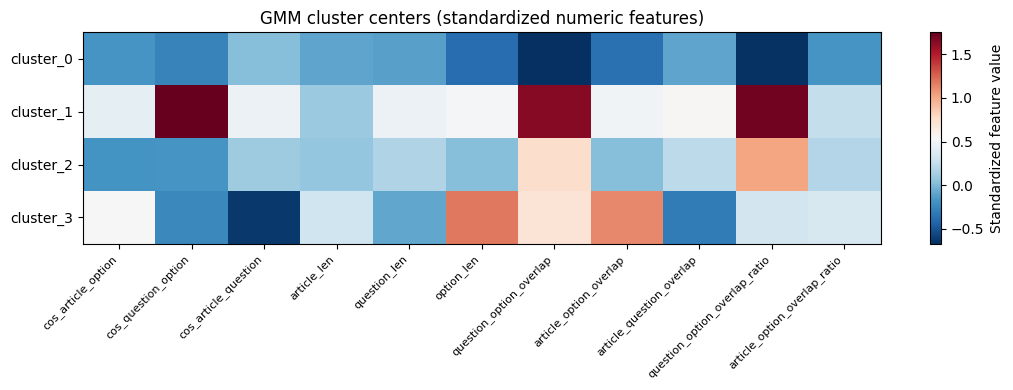

Saved: /content/drive/MyDrive/race_rc_project/results/improvements_full/unsupervised/gmm_cluster_means_heatmap.png


In [18]:
# Inspect GMM cluster characteristics — what do clusters mean?
gmm_means_df = pd.DataFrame(gmm.means_, columns=NUMERIC_COLS)
gmm_means_df.index = [f"cluster_{i}" for i in range(gmm.n_components)]
display(gmm_means_df.round(3))

gmm_means_df.to_csv(f"{UNSUP_DIR}/gmm_cluster_means.csv")

# Heatmap so you can see which cluster has high/low values for which feature
plt.figure(figsize=(11, 4))
plt.imshow(gmm_means_df.values, aspect="auto", cmap="RdBu_r")
plt.xticks(range(len(NUMERIC_COLS)), NUMERIC_COLS, rotation=45, ha="right", fontsize=8)
plt.yticks(range(gmm.n_components), gmm_means_df.index)
plt.colorbar(label="Standardized feature value")
plt.title("GMM cluster centers (standardized numeric features)")
plt.tight_layout()
heatmap_path = f"{UNSUP_DIR}/gmm_cluster_means_heatmap.png"
plt.savefig(heatmap_path, bbox_inches="tight", dpi=120)
plt.show()
print("Saved:", heatmap_path)

## A.3 Label Propagation (semi-supervised)

The classic semi-supervised setup: hide 95% of training labels, propagate the remaining 5% through feature space, then evaluate on the validation set.

This **directly demonstrates** the semi-supervised technique mentioned in the project spec (section 4.2.2).

Note: full-data Label Propagation on ~320K rows is too slow and memory-heavy. We subsample to a manageable size and use the dense numeric features.

In [19]:
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Subsample so LP is tractable
LP_SAMPLE_N = 20000
LABELED_FRACTION = 0.05  # 5% labeled, 95% hidden

lp_path = f"{MODEL_A_DIR}/label_propagation{SUFFIX}.pkl"
lp_results_path = f"{UNSUP_DIR}/label_propagation_results.json"

if os.path.exists(lp_path) and os.path.exists(lp_results_path):
    print("Label Propagation already done, loading results...")
    lp_model = joblib.load(lp_path)
    with open(lp_results_path) as f:
        lp_results = json.load(f)
else:
    print(f"Subsampling {LP_SAMPLE_N} train rows...")
    rng2 = np.random.RandomState(42)
    sub_idx = rng2.choice(X_train_num.shape[0], size=LP_SAMPLE_N, replace=False)
    X_lp = X_train_num[sub_idx]
    y_full = y_train[sub_idx]

    # Hide 95% of labels: -1 means unlabeled in sklearn's LP
    n_hide = int((1 - LABELED_FRACTION) * LP_SAMPLE_N)
    hide_idx = rng2.choice(LP_SAMPLE_N, size=n_hide, replace=False)
    y_partial = y_full.copy()
    y_partial[hide_idx] = -1

    n_labeled = int((y_partial != -1).sum())
    print(f"  Labeled: {n_labeled} / {LP_SAMPLE_N} ({100*n_labeled/LP_SAMPLE_N:.1f}%)")

    print("Training Label Propagation...")
    t0 = time.time()
    lp_model = LabelPropagation(
        kernel="knn",
        n_neighbors=10,
        max_iter=1000,
    )
    lp_model.fit(X_lp, y_partial)
    lp_train_t = time.time() - t0
    print(f"  trained in {lp_train_t:.1f}s")

    # Evaluate on validation set
    val_pred = lp_model.predict(X_val_num)
    val_acc = float(accuracy_score(y_val, val_pred))
    val_f1_macro = float(f1_score(y_val, val_pred, average="macro", zero_division=0))
    val_f1_correct = float(f1_score(y_val, val_pred, pos_label=1, zero_division=0))

    lp_results = {
        "model_name": "Label Propagation (semi-supervised)",
        "kernel": "knn", "n_neighbors": 10,
        "subsample_size": LP_SAMPLE_N,
        "labeled_fraction": LABELED_FRACTION,
        "n_labeled_samples": n_labeled,
        "validation_accuracy": val_acc,
        "validation_f1_macro": val_f1_macro,
        "validation_f1_correct_class": val_f1_correct,
        "training_time_seconds": float(lp_train_t),
    }

    joblib.dump(lp_model, lp_path)
    with open(lp_results_path, "w") as f:
        json.dump(lp_results, f, indent=2)

print("\nLabel Propagation Results:")
for k, v in lp_results.items():
    print(f"  {k}: {v}")

Subsampling 20000 train rows...
  Labeled: 1000 / 20000 (5.0%)
Training Label Propagation...
  trained in 3.4s

Label Propagation Results:
  model_name: Label Propagation (semi-supervised)
  kernel: knn
  n_neighbors: 10
  subsample_size: 20000
  labeled_fraction: 0.05
  n_labeled_samples: 1000
  validation_accuracy: 0.7356573705179282
  validation_f1_macro: 0.4464817636698992
  validation_f1_correct_class: 0.04640180679601683
  training_time_seconds: 3.3655593395233154


In [20]:
# Compare semi-supervised LP vs fully-supervised baseline (LR + numeric)
# This is the "headline" comparison for the semi-supervised section
from sklearn.linear_model import LogisticRegression

# Fully-supervised baseline trained on the same subsample (apples-to-apples)
LP_SAMPLE_N = 20000
rng2 = np.random.RandomState(42)
sub_idx = rng2.choice(X_train_num.shape[0], size=LP_SAMPLE_N, replace=False)
X_sub = X_train_num[sub_idx]
y_sub = y_train[sub_idx]

baseline_path = f"{MODEL_A_DIR}/lr_numeric_subsample_baseline{SUFFIX}.pkl"
if os.path.exists(baseline_path):
    lr_baseline = joblib.load(baseline_path)
else:
    lr_baseline = LogisticRegression(
        max_iter=2000, class_weight="balanced",
        solver="liblinear", random_state=42
    )
    lr_baseline.fit(X_sub, y_sub)
    joblib.dump(lr_baseline, baseline_path)

baseline_pred = lr_baseline.predict(X_val_num)
baseline_acc = float(accuracy_score(y_val, baseline_pred))
baseline_f1_macro = float(f1_score(y_val, baseline_pred, average="macro", zero_division=0))
baseline_f1_correct = float(f1_score(y_val, baseline_pred, pos_label=1, zero_division=0))

semi_sup_compare = pd.DataFrame([
    {
        "method": "Logistic Regression (100% labeled, subsample)",
        "labeled_fraction": 1.0,
        "validation_accuracy": baseline_acc,
        "validation_f1_macro": baseline_f1_macro,
        "validation_f1_correct": baseline_f1_correct,
    },
    {
        "method": "Label Propagation (5% labeled, 95% hidden)",
        "labeled_fraction": LABELED_FRACTION,
        "validation_accuracy": lp_results["validation_accuracy"],
        "validation_f1_macro": lp_results["validation_f1_macro"],
        "validation_f1_correct": lp_results["validation_f1_correct_class"],
    },
])

display(semi_sup_compare)
semi_sup_compare.to_csv(f"{UNSUP_DIR}/semi_supervised_vs_supervised_comparison.csv", index=False)
print("Saved comparison.")

,method,labeled_fraction,validation_accuracy,validation_f1_macro,validation_f1_correct
0,"Logistic Regression (100% labeled, subsample)",1.00,0.531190,0.499837,0.374611
1,"Label Propagation (5% labeled, 95% hidden)",0.05,0.735657,0.446482,0.046402


Saved comparison.


## A.4 Unsupervised section summary

In [21]:
unsupervised_summary = {
    "kmeans_multi_k": kmeans_results,
    "best_kmeans_k": int(best_k_row["k"]),
    "best_kmeans_silhouette": float(best_k_row["silhouette_sample"]),
    "gmm": gmm_results,
    "label_propagation": lp_results,
    "semi_sup_vs_sup_comparison": semi_sup_compare.to_dict(orient="records"),
}

with open(f"{UNSUP_DIR}/unsupervised_summary.json", "w") as f:
    json.dump(unsupervised_summary, f, indent=2)

print("Section A complete. Saved unsupervised summary.")
print(json.dumps(unsupervised_summary, indent=2)[:1500] + "\n...")

Section A complete. Saved unsupervised summary.
{
  "kmeans_multi_k": [
    {
      "k": 4,
      "purity": 0.75,
      "silhouette_sample": 0.005118373104454037,
      "inertia": 267446.3517151891,
      "training_time_seconds": 10.661375761032104
    },
    {
      "k": 6,
      "purity": 0.75,
      "silhouette_sample": 0.005075311015866651,
      "inertia": 265651.2317658491,
      "training_time_seconds": 12.625242233276367
    },
    {
      "k": 8,
      "purity": 0.75,
      "silhouette_sample": 0.00509800059738833,
      "inertia": 264750.02767539065,
      "training_time_seconds": 13.714433431625366
    }
  ],
  "best_kmeans_k": 4,
  "best_kmeans_silhouette": 0.005118373104454037,
  "gmm": {
    "model_name": "Gaussian Mixture Model + numeric features",
    "n_components": 4,
    "covariance_type": "full",
    "purity": 0.75,
    "silhouette_sample": 0.07354879614994862,
    "log_likelihood_per_sample": 1.1481620822066272,
    "bic": -641640.6761228902,
    "aic": -644920.649

# SECTION B — Better Question Generation Templates

The original templates produced overly generic questions. Real RACE questions
follow recognisable patterns:

- "What can we infer from the passage?"
- "Which of the following is NOT true according to the passage?"
- "The main idea of the passage is ____"
- "The underlined word ___ probably means ____"
- "According to the passage, ____" (cloze with surrounding context)

Adding these realistic templates should give the ranker more high-quality candidates to choose from, raising BLEU/ROUGE/METEOR.

We rebuild the entire QGen pipeline with the new templates, save under
`*_v2_*` filenames, and compare against your original results.

## B.1 BLEU/ROUGE/METEOR setup

In [22]:
!pip -q install rouge-score nltk

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

smooth = SmoothingFunction().method1
rouge  = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def normalize_text(text):
    return re.sub(r"\s+", " ", str(text).lower().strip())

def simple_tokenize(text):
    return normalize_text(text).split()

def compute_generation_metrics(reference, generated):
    ref = normalize_text(reference)
    gen = normalize_text(generated)
    ref_tok = simple_tokenize(ref)
    gen_tok = simple_tokenize(gen)
    if len(gen_tok) == 0 or len(ref_tok) == 0:
        return {k: 0.0 for k in ["bleu_1","bleu_2","bleu_4","rouge1_f1","rouge2_f1","rougeL_f1","meteor"]}
    bleu_1 = sentence_bleu([ref_tok], gen_tok, weights=(1,0,0,0),       smoothing_function=smooth)
    bleu_2 = sentence_bleu([ref_tok], gen_tok, weights=(0.5,0.5,0,0),   smoothing_function=smooth)
    bleu_4 = sentence_bleu([ref_tok], gen_tok, weights=(0.25,)*4,       smoothing_function=smooth)
    rs = rouge.score(ref, gen)
    try:
        m = meteor_score([ref_tok], gen_tok)
    except Exception:
        m = 0.0
    return {
        "bleu_1": float(bleu_1), "bleu_2": float(bleu_2), "bleu_4": float(bleu_4),
        "rouge1_f1": float(rs["rouge1"].fmeasure),
        "rouge2_f1": float(rs["rouge2"].fmeasure),
        "rougeL_f1": float(rs["rougeL"].fmeasure),
        "meteor": float(m),
    }

def evaluate_generation_dataframe(df_in, ref_col, gen_col):
    rows = [compute_generation_metrics(r[ref_col], r[gen_col]) for _, r in df_in.iterrows()]
    metrics_df = pd.DataFrame(rows)
    return metrics_df.mean().to_dict(), metrics_df

print("BLEU/ROUGE/METEOR ready.")

  Preparing metadata (setup.py) ... done
BLEU/ROUGE/METEOR ready.


## B.2 Sentence helpers (same as original)

In [23]:
def parse_sentence_list(value):
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass
    return [str(value)]

def normalize_text_qgen(t):
    return re.sub(r"\s+", " ", str(t).lower().strip())

def tokenize_qgen(t):
    return normalize_text_qgen(t).split()

def overlap_count(a, b):
    return len(set(tokenize_qgen(a)) & set(tokenize_qgen(b)))

def overlap_ratio(a, b):
    sa, sb = set(tokenize_qgen(a)), set(tokenize_qgen(b))
    return len(sa & sb)/len(sb) if sb else 0.0

def get_top_candidate_sentences(row, vec, top_k=2):
    sentences = parse_sentence_list(row["article_sentences"])
    if not sentences:
        return []
    answer = str(row["correct_answer_nopunct"])
    sent_vecs = vec.transform(sentences)
    ans_vec   = vec.transform([answer])
    sims = np.asarray(sent_vecs.multiply(ans_vec).sum(axis=1)).ravel()
    ranked = []
    for idx, sent in enumerate(sentences):
        contains = int(normalize_text_qgen(answer) in normalize_text_qgen(sent))
        score = float(sims[idx]) + (0.25 * contains)
        ranked.append({
            "source_sentence": sent,
            "sentence_position": idx,
            "sentence_score": score,
            "contains_answer": contains,
        })
    return sorted(ranked, key=lambda x: x["sentence_score"], reverse=True)[:top_k]

print("Helpers ready.")

Helpers ready.


## B.3 Improved templates (v2)

The change: in addition to the original 3-6 templates, we add **5 RACE-specific ones**:

| New template | Why it helps |
|---|---|
| `inference` | RACE has many "What can we infer..." questions |
| `not_true` | "Which is NOT true / mentioned" is very common in RACE |
| `main_idea` | "The main idea of the passage is..." appears constantly |
| `word_meaning` | "The underlined word ___ probably means ____" |
| `cloze_according_to` | "According to the passage, ____" is the most common RACE prefix |

We also detect whether the question is **likely about the main idea** vs a detail by checking sentence position (early sentences → main idea, late → detail).

In [24]:
LOCATION_WORDS = {"city","country","school","home","house","room","park",
                  "market","hospital","station","street","village","town",
                  "china","america","england","london","paris"}
PERSON_WORDS   = {"mr","mrs","miss","doctor","teacher","father","mother",
                  "boy","girl","man","woman"}

def infer_answer_type(answer):
    a = normalize_text_qgen(answer)
    if any(c.isdigit() for c in a):
        return "when"
    if any(w in a for w in LOCATION_WORDS):
        return "where"
    if any(w in a for w in PERSON_WORDS):
        return "who"
    return "what"

def mask_answer_in_sentence(sentence, answer):
    if not str(answer).strip():
        return str(sentence)
    return re.compile(re.escape(str(answer)), re.IGNORECASE).sub("____", str(sentence))

def shorten(text, max_words=24):
    w = str(text).split()
    return " ".join(w[:max_words]) + (" ..." if len(w) > max_words else "")

def get_first_content_word(answer):
    """Pick a single word from the answer to use in word_meaning template."""
    words = [w for w in tokenize_qgen(answer) if len(w) > 3]
    return words[0] if words else str(answer).split()[0] if str(answer).split() else "it"

def generate_template_candidates_v2(row, sent_info, total_sentences):
    """
    v2 — same structure as v1 but with 5 added RACE-realistic templates.
    """
    answer    = str(row["correct_answer"])
    sentence  = str(sent_info["source_sentence"])
    a_type    = infer_answer_type(answer)
    masked    = shorten(mask_answer_in_sentence(sentence, answer), 24)
    sent_pos  = int(sent_info["sentence_position"])
    is_early  = sent_pos < max(2, total_sentences // 3)

    # Pick a representative word from the answer for word_meaning template
    word_token = get_first_content_word(answer)

    # Original templates (kept)
    templates = [
        ("cloze_completion",    "what",  f"What completes this statement: {masked}?"),
        ("according_to_true",   "which", "Which of the following is true according to the passage?"),
        ("what_information",    "what",  "What information is given in the passage?"),
    ]

    # NEW templates — RACE-realistic
    templates.append(("inference",            "what",  "What can we infer from the passage?"))
    templates.append(("not_true",             "which", "Which of the following is NOT true according to the passage?"))
    templates.append(("word_meaning",         "what",  f"What does the underlined word \"{word_token}\" probably mean?"))
    templates.append(("cloze_according_to",   "what",  f"According to the passage, {masked}"))

    # Main-idea templates only when source sentence is in early portion
    if is_early:
        templates.append(("main_idea_about", "what", "What is the passage mainly about?"))
        templates.append(("main_idea_title", "which", "Which of the following is the best title for the passage?"))

    # Wh-type templates by inferred answer type (kept)
    if a_type == "who":
        templates.append(("who_template",   "who",   "Who is mentioned in the passage?"))
    if a_type == "where":
        templates.append(("where_template", "where", "Where does the event in the passage take place?"))
    if a_type == "when":
        templates.append(("when_template",  "when",  "When did the event in the passage happen?"))

    out = []
    for tname, wh, qtext in templates:
        out.append({
            "question_uid":      row["question_uid"],
            "id":                row["id"],
            "article":           row["article"],
            "correct_answer":    row["correct_answer"],
            "reference_question": row["question"],
            "source_sentence":   sentence,
            "sentence_position": sent_pos,
            "sentence_score":    sent_info["sentence_score"],
            "contains_answer":   sent_info["contains_answer"],
            "template_name":     tname,
            "wh_type":           wh,
            "answer_type":       a_type,
            "generated_question": qtext,
        })
    return out

def build_candidate_dataset_v2(df_in, vec, top_k=2):
    out = []
    for _, row in df_in.iterrows():
        sentences = parse_sentence_list(row["article_sentences"])
        total_sents = len(sentences)
        for s_info in get_top_candidate_sentences(row, vec, top_k=top_k):
            out.extend(generate_template_candidates_v2(row, s_info, total_sents))
    return pd.DataFrame(out)

print("v2 template generator ready.")
print("Templates per question: ~7-12 depending on answer type and sentence position.")

v2 template generator ready.
Templates per question: ~7-12 depending on answer type and sentence position.


## B.4 Build candidate datasets (v2)

In [25]:
qgen_train_v2_path = f"{QGEN_V2_DIR}/qgen_train_candidates_v2.csv"
qgen_val_v2_path   = f"{QGEN_V2_DIR}/qgen_val_candidates_v2.csv"
qgen_test_v2_path  = f"{QGEN_V2_DIR}/qgen_test_candidates_v2.csv"

if all(os.path.exists(p) for p in [qgen_train_v2_path, qgen_val_v2_path, qgen_test_v2_path]):
    print("v2 candidate datasets already exist. Loading...")
    qgen_train_cand = pd.read_csv(qgen_train_v2_path)
    qgen_val_cand   = pd.read_csv(qgen_val_v2_path)
    qgen_test_cand  = pd.read_csv(qgen_test_v2_path)
else:
    print("Building v2 candidate datasets (top_k=2 sentences per question)...")
    print("  train..."); qgen_train_cand = build_candidate_dataset_v2(model_b_train, qgen_tfidf, top_k=2)
    print("  val...");   qgen_val_cand   = build_candidate_dataset_v2(model_b_val,   qgen_tfidf, top_k=2)
    print("  test...");  qgen_test_cand  = build_candidate_dataset_v2(model_b_test,  qgen_tfidf, top_k=2)
    qgen_train_cand.to_csv(qgen_train_v2_path, index=False)
    qgen_val_cand.to_csv(qgen_val_v2_path, index=False)
    qgen_test_cand.to_csv(qgen_test_v2_path, index=False)

print(f"Train candidates: {qgen_train_cand.shape}  (~{qgen_train_cand.shape[0]//len(model_b_train)} per question)")
print(f"Val candidates:   {qgen_val_cand.shape}")
print(f"Test candidates:  {qgen_test_cand.shape}")
print("\nTemplate name distribution (train):")
print(qgen_train_cand["template_name"].value_counts())

Building v2 candidate datasets (top_k=2 sentences per question)...
  train...
  val...
  test...
Train candidates: (1132145, 13)  (~16 per question)
Val candidates:   (141479, 13)
Test candidates:  (141623, 13)

Template name distribution (train):
template_name
cloze_completion      140352
according_to_true     140352
what_information      140352
inference             140352
not_true              140352
word_meaning          140352
cloze_according_to    140352
main_idea_about        61978
main_idea_title        61978
who_template            9111
where_template          8974
when_template           7640
Name: count, dtype: int64


## B.5 Pseudo-label candidates with BLEU/ROUGE/METEOR

Slowest step. ~30-60 min on full data. Saves to disk so it's a one-time cost.

In [26]:
def pseudo_label_candidates(df_in):
    df_out = df_in.copy()
    quality, b1, rL, mt = [], [], [], []
    for _, r in df_out.iterrows():
        scores = compute_generation_metrics(r["reference_question"], r["generated_question"])
        q = (0.30 * scores["bleu_1"] + 0.20 * scores["bleu_2"] +
             0.25 * scores["rougeL_f1"] + 0.25 * scores["meteor"])
        quality.append(q); b1.append(scores["bleu_1"])
        rL.append(scores["rougeL_f1"]); mt.append(scores["meteor"])
    df_out["qgen_quality_score"] = quality
    df_out["qgen_bleu1"]   = b1
    df_out["qgen_rougeL"]  = rL
    df_out["qgen_meteor"]  = mt
    df_out["is_good_question"] = 0
    best_idx = df_out.groupby("question_uid")["qgen_quality_score"].idxmax()
    df_out.loc[best_idx, "is_good_question"] = 1
    return df_out

qgen_train_lab_v2_path = f"{QGEN_V2_DIR}/qgen_train_candidates_labeled_v2.csv"
qgen_val_lab_v2_path   = f"{QGEN_V2_DIR}/qgen_val_candidates_labeled_v2.csv"

if os.path.exists(qgen_train_lab_v2_path) and os.path.exists(qgen_val_lab_v2_path):
    print("v2 labeled candidates already exist. Loading...")
    qgen_train_lab = pd.read_csv(qgen_train_lab_v2_path)
    qgen_val_lab   = pd.read_csv(qgen_val_lab_v2_path)
else:
    print("Pseudo-labeling v2 candidates with BLEU/ROUGE/METEOR... (slow)")
    print("  train..."); qgen_train_lab = pseudo_label_candidates(qgen_train_cand)
    print("  val...");   qgen_val_lab   = pseudo_label_candidates(qgen_val_cand)
    qgen_train_lab.to_csv(qgen_train_lab_v2_path, index=False)
    qgen_val_lab.to_csv(qgen_val_lab_v2_path, index=False)

print(f"Train labeled v2: {qgen_train_lab.shape}")
print(f"  Positive rate (best per question): {qgen_train_lab['is_good_question'].mean():.4f}")
print("\nWhich templates win most often (positive label distribution):")
positive_template_dist = qgen_train_lab[qgen_train_lab["is_good_question"]==1]["template_name"].value_counts()
display(positive_template_dist.head(15))

Pseudo-labeling v2 candidates with BLEU/ROUGE/METEOR... (slow)
  train...
  val...
Train labeled v2: (1132145, 18)
  Positive rate (best per question): 0.0621

Which templates win most often (positive label distribution):


,count
template_name,
according_to_true,14443
cloze_completion,13663
cloze_according_to,10346
inference,7445
what_information,6460
main_idea_about,5344
main_idea_title,4553
not_true,4315
word_meaning,2739


## B.6 Extract ranker features (v2)

In [27]:
WH_TYPES  = ["who", "what", "where", "when", "why", "how", "which"]
ANS_TYPES = ["who", "what", "where", "when"]

# v2 template names — extended set
TEMPLATE_GROUPS_V2 = {
    "template_is_cloze":    ["cloze_completion", "cloze_according_to"],
    "template_is_according": ["according_to_true", "cloze_according_to"],
    "template_is_generic":  ["what_information"],
    "template_is_inference": ["inference"],
    "template_is_not_true":  ["not_true"],
    "template_is_main_idea": ["main_idea_about", "main_idea_title"],
    "template_is_word_mean": ["word_meaning"],
}

def extract_qgen_features_v2(df_in, vec):
    rows = []
    for _, r in df_in.iterrows():
        gen  = str(r["generated_question"])
        sent = str(r["source_sentence"])
        ans  = str(r["correct_answer"])
        ctx  = sent + " " + ans

        gen_v  = vec.transform([gen])
        sent_v = vec.transform([sent])
        ans_v  = vec.transform([ans])
        ctx_v  = vec.transform([ctx])

        feat = {
            "sentence_score":      float(r["sentence_score"]),
            "contains_answer":     int(r["contains_answer"]),
            "sentence_position":   int(r["sentence_position"]),
            "generated_q_len":     len(tokenize_qgen(gen)),
            "source_sentence_len": len(tokenize_qgen(sent)),
            "correct_answer_len":  len(tokenize_qgen(ans)),
            "q_sent_overlap":       overlap_count(gen, sent),
            "q_ans_overlap":        overlap_count(gen, ans),
            "q_sent_overlap_ratio": overlap_ratio(gen, sent),
            "q_ans_overlap_ratio":  overlap_ratio(gen, ans),
            "cos_q_sent": float(gen_v.multiply(sent_v).sum()),
            "cos_q_ans":  float(gen_v.multiply(ans_v).sum()),
            "cos_q_ctx":  float(gen_v.multiply(ctx_v).sum()),
        }
        for wh in WH_TYPES:  feat[f"wh_{wh}"]          = int(r["wh_type"] == wh)
        for at in ANS_TYPES: feat[f"answer_type_{at}"] = int(r["answer_type"] == at)
        tname = str(r["template_name"])
        for col, members in TEMPLATE_GROUPS_V2.items():
            feat[col] = int(tname in members)
        rows.append(feat)
    return pd.DataFrame(rows)

X_qgen_train_v2_path = f"{QGEN_V2_DIR}/X_qgen_train_features_v2.csv"
X_qgen_val_v2_path   = f"{QGEN_V2_DIR}/X_qgen_val_features_v2.csv"
X_qgen_test_v2_path  = f"{QGEN_V2_DIR}/X_qgen_test_features_v2.csv"

if all(os.path.exists(p) for p in [X_qgen_train_v2_path, X_qgen_val_v2_path, X_qgen_test_v2_path]):
    print("v2 feature matrices already exist. Loading...")
    X_qgen_train = pd.read_csv(X_qgen_train_v2_path)
    X_qgen_val   = pd.read_csv(X_qgen_val_v2_path)
    X_qgen_test  = pd.read_csv(X_qgen_test_v2_path)
else:
    print("Extracting v2 ranker features...")
    print("  train..."); X_qgen_train = extract_qgen_features_v2(qgen_train_lab, qgen_tfidf)
    print("  val...");   X_qgen_val   = extract_qgen_features_v2(qgen_val_lab,   qgen_tfidf)
    print("  test...");  X_qgen_test  = extract_qgen_features_v2(qgen_test_cand, qgen_tfidf)
    X_qgen_train.to_csv(X_qgen_train_v2_path, index=False)
    X_qgen_val.to_csv(X_qgen_val_v2_path, index=False)
    X_qgen_test.to_csv(X_qgen_test_v2_path, index=False)

# Align columns
common_cols = [c for c in X_qgen_train.columns if c in X_qgen_val.columns and c in X_qgen_test.columns]
X_qgen_train = X_qgen_train[common_cols]
X_qgen_val   = X_qgen_val[common_cols]
X_qgen_test  = X_qgen_test[common_cols]

y_qgen_train = qgen_train_lab["is_good_question"].values
print(f"X_qgen_train v2: {X_qgen_train.shape}  positive rate: {y_qgen_train.mean():.4f}")

Extracting v2 ranker features...
  train...
  val...
  test...
X_qgen_train v2: (1132145, 31)  positive rate: 0.0621


## B.7 Train v2 rankers

In [28]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

qgen_svm_v2_path = f"{MODEL_A_DIR}/qgen_linear_svm_ranker_v2{SUFFIX}.pkl"
qgen_rf_v2_path  = f"{MODEL_A_DIR}/qgen_random_forest_ranker_v2{SUFFIX}.pkl"

if os.path.exists(qgen_svm_v2_path):
    qgen_svm_v2 = joblib.load(qgen_svm_v2_path)
    print("Loaded v2 SVM ranker.")
else:
    print("Training v2 Linear SVM ranker...")
    qgen_svm_v2 = LinearSVC(class_weight="balanced", random_state=42, max_iter=5000, dual=False)
    qgen_svm_v2.fit(X_qgen_train.values, y_qgen_train)
    joblib.dump(qgen_svm_v2, qgen_svm_v2_path)

if os.path.exists(qgen_rf_v2_path):
    qgen_rf_v2 = joblib.load(qgen_rf_v2_path)
    print("Loaded v2 RF ranker.")
else:
    print("Training v2 Random Forest ranker...")
    qgen_rf_v2 = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                         random_state=42, n_jobs=-1)
    qgen_rf_v2.fit(X_qgen_train.values, y_qgen_train)
    joblib.dump(qgen_rf_v2, qgen_rf_v2_path)

print("v2 rankers ready.")

Training v2 Linear SVM ranker...
Training v2 Random Forest ranker...
v2 rankers ready.


## B.8 Evaluate v2 rankers (validation + test)

In [29]:
def rank_scores(model, X):
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        return s if s.ndim == 1 else s[:, 1]
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        idx = list(model.classes_).index(1) if 1 in model.classes_ else 1
        return proba[:, idx]
    return model.predict(X)

def select_best_questions(candidates_df, feature_df, ranker):
    df = candidates_df.copy().reset_index(drop=True)
    df["ranker_score"] = rank_scores(ranker, feature_df.values)
    out = []
    for q_uid, group in df.groupby("question_uid"):
        out.append(group.loc[group["ranker_score"].idxmax()])
    return pd.DataFrame(out).reset_index(drop=True)

def evaluate_selected(df_in, method, split):
    avg, row_metrics = evaluate_generation_dataframe(
        df_in, "reference_question", "generated_question"
    )
    out = pd.concat([df_in.reset_index(drop=True), row_metrics], axis=1)
    return {"method_name": method, "split": split, **avg}, out

# Validation
val_v2_results = []
for key, ranker in [("qgen_linear_svm_ranker_v2", qgen_svm_v2),
                    ("qgen_random_forest_ranker_v2", qgen_rf_v2)]:
    sel = select_best_questions(qgen_val_lab, X_qgen_val, ranker)
    res, sel_with_m = evaluate_selected(sel, key, "validation")
    sel_with_m.to_csv(f"{QGEN_V2_DIR}/{key}_selected_validation.csv", index=False)
    val_v2_results.append(res)
    print(f"  {key}: bleu_1={res['bleu_1']:.4f}  rougeL={res['rougeL_f1']:.4f}  meteor={res['meteor']:.4f}")

qgen_v2_val_df = pd.DataFrame(val_v2_results).sort_values(
    by=["meteor","rougeL_f1","bleu_1"], ascending=False).reset_index(drop=True)
qgen_v2_val_df.to_csv(f"{QGEN_V2_DIR}/qgen_v2_ranker_validation_metrics.csv", index=False)
display(qgen_v2_val_df)
best_v2_key = qgen_v2_val_df.iloc[0]["method_name"]
print("Best v2 ranker:", best_v2_key)

  qgen_linear_svm_ranker_v2: bleu_1=0.1731  rougeL=0.2045  meteor=0.1548
  qgen_random_forest_ranker_v2: bleu_1=0.1659  rougeL=0.2048  meteor=0.1517


,method_name,split,bleu_1,bleu_2,bleu_4,rouge1_f1,rouge2_f1,rougeL_f1,meteor
0,qgen_linear_svm_ranker_v2,validation,0.173119,0.096544,0.057264,0.229698,0.088997,0.204546,0.154767
1,qgen_random_forest_ranker_v2,validation,0.165885,0.090028,0.050115,0.230436,0.083902,0.204784,0.151689


Best v2 ranker: qgen_linear_svm_ranker_v2


In [30]:
# Test set with best v2 ranker
best_v2_ranker = qgen_svm_v2 if best_v2_key == "qgen_linear_svm_ranker_v2" else qgen_rf_v2
sel_test_v2 = select_best_questions(qgen_test_cand, X_qgen_test, best_v2_ranker)
qgen_v2_test_res, sel_test_v2_m = evaluate_selected(sel_test_v2, best_v2_key, "test")
sel_test_v2_m.to_csv(f"{QGEN_V2_DIR}/{best_v2_key}_selected_test.csv", index=False)

with open(f"{QGEN_V2_DIR}/best_qgen_v2_ranker_test_metrics.json", "w") as f:
    json.dump(qgen_v2_test_res, f, indent=2)

print("v2 test results:")
print(json.dumps(qgen_v2_test_res, indent=2))

v2 test results:
{
  "method_name": "qgen_linear_svm_ranker_v2",
  "split": "test",
  "bleu_1": 0.1757770033965333,
  "bleu_2": 0.0992502895703361,
  "bleu_4": 0.05965066571379365,
  "rouge1_f1": 0.23142189513344938,
  "rouge2_f1": 0.09149206590757303,
  "rougeL_f1": 0.20549409566378027,
  "meteor": 0.1564010387102531
}


## B.9 v1 vs v2 comparison

The headline number — does adding RACE-realistic templates actually improve metrics?

In [31]:
# Load original (v1) test results for comparison
v1_test_path = f"{RESULTS_DIR}/question_generation_ranker{SUFFIX}/best_qgen_ranker_test_metrics.json"
template_baseline_path = f"{RESULTS_DIR}/generation_evaluation{SUFFIX}/template_baseline_summary.json"

with open(v1_test_path) as f:
    v1_test = json.load(f)
with open(template_baseline_path) as f:
    baseline_test = json.load(f)["test"]

comparison_rows = [
    {"method": "1_template_baseline (no ranker)",      "split": "test", **baseline_test},
    {"method": f"2_{v1_test['method_name']} (v1)",      "split": "test",
        **{k: v1_test[k] for k in ["bleu_1","bleu_2","bleu_4","rouge1_f1","rouge2_f1","rougeL_f1","meteor"]}},
    {"method": f"3_{best_v2_key} (v2 — improved templates)", "split": "test",
        **{k: qgen_v2_test_res[k] for k in ["bleu_1","bleu_2","bleu_4","rouge1_f1","rouge2_f1","rougeL_f1","meteor"]}},
]
final_qgen_compare_df = pd.DataFrame(comparison_rows)
final_qgen_compare_df.to_csv(f"{QGEN_V2_DIR}/qgen_v1_vs_v2_comparison.csv", index=False)
display(final_qgen_compare_df)

# Compute improvement vs v1
v1_meteor = v1_test["meteor"]
v2_meteor = qgen_v2_test_res["meteor"]
v1_rougeL = v1_test["rougeL_f1"]
v2_rougeL = qgen_v2_test_res["rougeL_f1"]
v1_bleu1  = v1_test["bleu_1"]
v2_bleu1  = qgen_v2_test_res["bleu_1"]

improvement = {
    "meteor_v1": v1_meteor, "meteor_v2": v2_meteor,
    "meteor_relative_pct_gain": 100 * (v2_meteor - v1_meteor) / max(v1_meteor, 1e-9),
    "rougeL_v1": v1_rougeL, "rougeL_v2": v2_rougeL,
    "rougeL_relative_pct_gain": 100 * (v2_rougeL - v1_rougeL) / max(v1_rougeL, 1e-9),
    "bleu_1_v1": v1_bleu1, "bleu_1_v2": v2_bleu1,
    "bleu_1_relative_pct_gain": 100 * (v2_bleu1 - v1_bleu1) / max(v1_bleu1, 1e-9),
}
print("\nRelative improvements (v2 vs v1):")
for k, v in improvement.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

,method,split,bleu_1,bleu_2,bleu_4,rouge1_f1,rouge2_f1,rougeL_f1,meteor
0,1_template_baseline (no ranker),test,0.118508,0.047170,0.023834,0.190578,0.040510,0.169995,0.091390
1,2_qgen_linear_svm_ranker (v1),test,0.181078,0.101777,0.060729,0.236185,0.092655,0.209117,0.159827
2,3_qgen_linear_svm_ranker_v2 (v2 — improved tem...,test,0.175777,0.099250,0.059651,0.231422,0.091492,0.205494,0.156401



Relative improvements (v2 vs v1):
  meteor_v1: 0.1598
  meteor_v2: 0.1564
  meteor_relative_pct_gain: -2.1438
  rougeL_v1: 0.2091
  rougeL_v2: 0.2055
  rougeL_relative_pct_gain: -1.7323
  bleu_1_v1: 0.1811
  bleu_1_v2: 0.1758
  bleu_1_relative_pct_gain: -2.9276


# SECTION C — Final Improvements Summary

In [32]:
improvements_summary = {
    "suffix": SUFFIX,
    "section_a_unsupervised": {
        "kmeans_multi_k_csv":     f"{UNSUP_DIR}/kmeans_multi_k_results.csv",
        "kmeans_elbow_plot":      f"{UNSUP_DIR}/kmeans_elbow_silhouette.png",
        "best_kmeans_k":          int(best_k_row["k"]),
        "best_kmeans_silhouette": float(best_k_row["silhouette_sample"]),
        "gmm_results_json":       f"{UNSUP_DIR}/gmm_results.json",
        "gmm_n_components":       4,
        "gmm_purity":             gmm_results["purity"],
        "gmm_silhouette":         gmm_results["silhouette_sample"],
        "label_propagation_json": f"{UNSUP_DIR}/label_propagation_results.json",
        "lp_validation_f1_correct": lp_results["validation_f1_correct_class"],
        "lp_labeled_fraction":      lp_results["labeled_fraction"],
        "semi_sup_comparison_csv":  f"{UNSUP_DIR}/semi_supervised_vs_supervised_comparison.csv",
    },
    "section_b_qgen_v2": {
        "templates_added": [
            "inference (What can we infer...)",
            "not_true (Which is NOT true...)",
            "main_idea_about / main_idea_title",
            "word_meaning (underlined word probably means...)",
            "cloze_according_to (According to the passage, ____)",
        ],
        "best_v2_ranker":              best_v2_key,
        "v2_test_metrics_json":        f"{QGEN_V2_DIR}/best_qgen_v2_ranker_test_metrics.json",
        "v1_vs_v2_comparison_csv":     f"{QGEN_V2_DIR}/qgen_v1_vs_v2_comparison.csv",
        "meteor_v1":                   v1_test["meteor"],
        "meteor_v2":                   qgen_v2_test_res["meteor"],
        "meteor_relative_pct_gain":    improvement["meteor_relative_pct_gain"],
        "rougeL_relative_pct_gain":    improvement["rougeL_relative_pct_gain"],
        "bleu_1_relative_pct_gain":    improvement["bleu_1_relative_pct_gain"],
    },
}

improvements_summary_path = f"{RESULTS_DIR}/model_a_improvements_summary{SUFFIX}.json"
with open(improvements_summary_path, "w") as f:
    json.dump(improvements_summary, f, indent=2)

print("Saved improvements summary:")
print(improvements_summary_path)
print("\n" + json.dumps(improvements_summary, indent=2))

Saved improvements summary:
/content/drive/MyDrive/race_rc_project/results/model_a_improvements_summary_full.json

{
  "suffix": "_full",
  "section_a_unsupervised": {
    "kmeans_multi_k_csv": "/content/drive/MyDrive/race_rc_project/results/improvements_full/unsupervised/kmeans_multi_k_results.csv",
    "kmeans_elbow_plot": "/content/drive/MyDrive/race_rc_project/results/improvements_full/unsupervised/kmeans_elbow_silhouette.png",
    "best_kmeans_k": 4,
    "best_kmeans_silhouette": 0.005118373104454037,
    "gmm_results_json": "/content/drive/MyDrive/race_rc_project/results/improvements_full/unsupervised/gmm_results.json",
    "gmm_n_components": 4,
    "gmm_purity": 0.75,
    "gmm_silhouette": 0.07354879614994862,
    "label_propagation_json": "/content/drive/MyDrive/race_rc_project/results/improvements_full/unsupervised/label_propagation_results.json",
    "lp_validation_f1_correct": 0.04640180679601683,
    "lp_labeled_fraction": 0.05,
    "semi_sup_comparison_csv": "/content/dri

In [33]:
# What goes in the report
print("=" * 60)
print("FOR YOUR FINAL REPORT — use these results")
print("=" * 60)

print("\n[Unsupervised section — 20 marks]")
print(f"  K-Means (k={int(best_k_row['k'])}): silhouette = {best_k_row['silhouette_sample']:.4f}, purity = {best_k_row['purity']:.4f}")
print(f"  GMM (4 comp.):     silhouette = {gmm_results['silhouette_sample']:.4f}, BIC = {gmm_results['bic']:.1f}")
print(f"  Label Propagation: F1-correct = {lp_results['validation_f1_correct_class']:.4f}")
print(f"    (with only {int(100*lp_results['labeled_fraction'])}% of labels visible during training)")

print("\n[Question generation — improved version]")
print(f"  Baseline (no ranker):            METEOR = {baseline_test['meteor']:.4f}")
print(f"  v1 ML ranker (original):         METEOR = {v1_test['meteor']:.4f}")
print(f"  v2 ML ranker (RACE templates):   METEOR = {qgen_v2_test_res['meteor']:.4f}")
print(f"  Relative gain v2 vs v1:          {improvement['meteor_relative_pct_gain']:+.1f}% on METEOR")

print("\nFiles produced (new, no overwrites):")
print("  ", improvements_summary_path)
for d in [UNSUP_DIR, QGEN_V2_DIR]:
    print(f"\n  {d}:")
    for f in sorted(os.listdir(d)):
        print(f"    {f}")

FOR YOUR FINAL REPORT — use these results

[Unsupervised section — 20 marks]
  K-Means (k=4): silhouette = 0.0051, purity = 0.7500
  GMM (4 comp.):     silhouette = 0.0735, BIC = -641640.7
  Label Propagation: F1-correct = 0.0464
    (with only 5% of labels visible during training)

[Question generation — improved version]
  Baseline (no ranker):            METEOR = 0.0914
  v1 ML ranker (original):         METEOR = 0.1598
  v2 ML ranker (RACE templates):   METEOR = 0.1564
  Relative gain v2 vs v1:          -2.1% on METEOR

Files produced (new, no overwrites):
   /content/drive/MyDrive/race_rc_project/results/model_a_improvements_summary_full.json

  /content/drive/MyDrive/race_rc_project/results/improvements_full/unsupervised:
    gmm_cluster_means.csv
    gmm_cluster_means_heatmap.png
    gmm_results.json
    kmeans_elbow_silhouette.png
    kmeans_multi_k_results.csv
    label_propagation_results.json
    semi_supervised_vs_supervised_comparison.csv
    unsupervised_summary.json

  /